In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
dataset = pd.read_csv(r"C:\Users\91958\Desktop\Machine Learning\datasets\insurance.csv")
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
dataset.shape

(1338, 7)

In [7]:
X = dataset.drop("charges", axis=1)
y = dataset["charges"]

In [8]:
X = pd.get_dummies(X, drop_first=True)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = ElasticNet(alpha=1.0, l1_ratio=0.5)

model.fit(X_train, y_train)

ElasticNet()

In [12]:
y_pred = model.predict(X_test)

In [13]:
comparison = pd.DataFrame({
    "Actual Charges": y_test,
    "Predicted Charges": y_pred
})

comparison

,Actual Charges,Predicted Charges
764,9095.06825,10118.977488
887,5272.17580,8806.753580
890,29330.98315,28387.554163
1293,9301.89355,10846.887219
259,33750.29180,22322.095326
...,...,...
109,47055.53210,30774.440649
575,12222.89830,11829.303382
535,6067.12675,9554.566966
543,63770.42801,31809.757212


In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 5271.295916876081
Mean Squared Error: 49175838.480035536
Root Mean Squared Error: 7012.548643684087
R² Score: 0.6832448290719766


In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,age,2352.923873
1,bmi,1392.913961
2,children,426.636913
3,sex_male,150.078870
4,smoker_yes,6312.905547
5,region_northwest,-94.735731
6,region_southeast,61.670696
7,region_southwest,-186.741642


In [16]:
selected_features = coefficients[
    coefficients["Coefficient"] != 0
]

selected_features

,Feature,Coefficient
0,age,2352.923873
1,bmi,1392.913961
2,children,426.636913
3,sex_male,150.078870
4,smoker_yes,6312.905547
5,region_northwest,-94.735731
6,region_southeast,61.670696
7,region_southwest,-186.741642


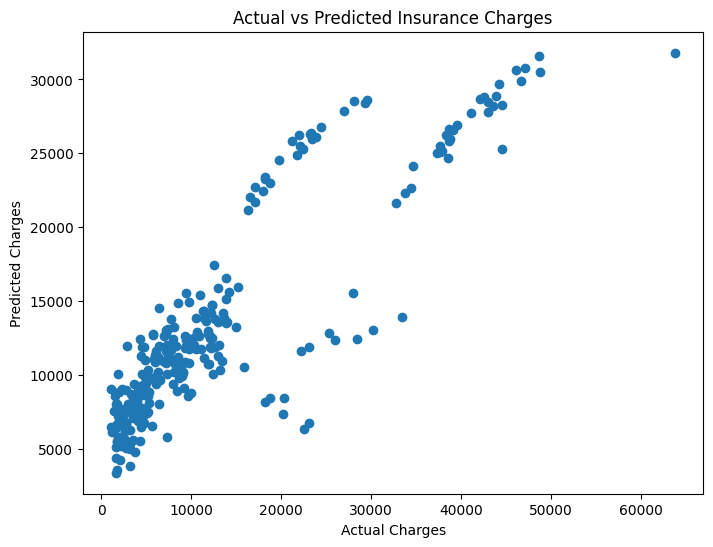

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

In [18]:
alphas = [0.01, 0.1, 1, 10]
l1_ratios = [0.2, 0.5, 0.8]

for alpha in alphas:
    for ratio in l1_ratios:

        model = ElasticNet(alpha=alpha, l1_ratio=ratio)

        model.fit(X_train, y_train)

        score = model.score(X_test, y_test)

        print(
            f"Alpha = {alpha} | L1 Ratio = {ratio} | R² Score = {score:.4f}"
        )

Alpha = 0.01 | L1 Ratio = 0.2 | R² Score = 0.7831
Alpha = 0.01 | L1 Ratio = 0.5 | R² Score = 0.7833
Alpha = 0.01 | L1 Ratio = 0.8 | R² Score = 0.7835
Alpha = 0.1 | L1 Ratio = 0.2 | R² Score = 0.7754
Alpha = 0.1 | L1 Ratio = 0.5 | R² Score = 0.7793
Alpha = 0.1 | L1 Ratio = 0.8 | R² Score = 0.7822
Alpha = 1 | L1 Ratio = 0.2 | R² Score = 0.6141
Alpha = 1 | L1 Ratio = 0.5 | R² Score = 0.6832
Alpha = 1 | L1 Ratio = 0.8 | R² Score = 0.7537
Alpha = 10 | L1 Ratio = 0.2 | R² Score = 0.1593
Alpha = 10 | L1 Ratio = 0.5 | R² Score = 0.2320
Alpha = 10 | L1 Ratio = 0.8 | R² Score = 0.4225


In [19]:
new_customer = pd.DataFrame({
    "age": [30],
    "bmi": [28.5],
    "children": [2],
    "sex_male": [1],
    "smoker_yes": [0],
    "region_northwest": [0],
    "region_southeast": [1],
    "region_southwest": [0]
})

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

print("Predicted Insurance Charges:", prediction[0])

Predicted Insurance Charges: 11406.601650757262
